In [1]:
import requests
import json

url = "https://azure-prd.gadnr.org/CIG/Default.aspx"

params = {
    "Recipient": "",
    "ProjectName": "",
    "PrincipalInvestigator": "",
    "Year": 0,
    "GrantCycle": 0,
    "GrantAward": "",
    "AwardType": 0,
    "ProjectType": 0,
    "RecipientCategory": 0,
    "Counties": "",
    "Themes": "",
    "PageIndex": 0,
    "SortExpression": "",
    "SortDirection": "Ascending"
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.url)
print(response.text[:500])

200
https://azure-prd.gadnr.org/CIG/Default.aspx?Recipient=&ProjectName=&PrincipalInvestigator=&Year=0&GrantCycle=0&GrantAward=&AwardType=0&ProjectType=0&RecipientCategory=0&Counties=&Themes=&PageIndex=0&SortExpression=&SortDirection=Ascending


<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">
<html xmlns="http://www.w3.org/1999/xhtml" xml:lang="en">
<head><title>
	Home Page
</title><link href="Styles/Site.css" rel="stylesheet" type="text/css" />
    <script type="text/javascript">
        function confirmDelete() {
            return (confirm("CIG Project # -1 shall be deleted. Please confirm."));
        }
    </script>
<style type="text/css">
    .auto-style1


In [2]:
import pandas as pd

from io import StringIO

tables = pd.read_html(StringIO(response.text))

print("Number of tables:", len(tables))

for i, table in enumerate(tables):
    print("\nTable", i)
    print(table.shape)
    print(table.columns.tolist())
    print(table.head(2))

Number of tables: 4

Table 0
(1, 1)
[0]
                                                   0
0  [Search]  Recipient  Principal Investigator  R...

Table 1
(9, 4)
[0, 1, 2, 3]
     0    1    2         3
0  NaN  NaN  NaN  [Search]
1  NaN  NaN  NaN       NaN

Table 2
(26, 12)
['Project ID', 'Recipient', 'Project Title', 'Principal Investigator', 'Keywords', 'Year', 'Counties', 'Grant Cycle', 'Award Amount', 'Award Type', 'Project Type', 'Recipient Category']
  Project ID                                          Recipient  \
0          1  Sapelo Island National Estuarine Research Rese...   
1          2                                       Glynn County   

                                       Project Title Principal Investigator  \
0  Water Quality Monitoring Program for Sapelo Is...         Hill, Sullivan   
1                         Boat Ramp Repairs-Phase II                Gilmour   

        Keywords  Year  Counties Grant Cycle Award Amount Award Type  \
0  Water Quality  1999  McIn

In [3]:
import requests
import pandas as pd
from io import StringIO
import time
'''
url = "https://azure-prd.gadnr.org/CIG/Default.aspx"

params = {
    "Recipient": "",
    "ProjectName": "",
    "PrincipalInvestigator": "",
    "Year": 0,
    "GrantCycle": 0,
    "GrantAward": "",
    "AwardType": 0,
    "ProjectType": 0,
    "RecipientCategory": 0,
    "Counties": "",
    "Themes": "",
    "PageIndex": 0,
    "SortExpression": "",
    "SortDirection": "Ascending"
}

session = requests.Session()

all_pages = []

for page in range(0, 1000):
    params["PageIndex"] = page

    response = session.get(url, params=params, timeout=30)
    response.raise_for_status()

    tables = pd.read_html(StringIO(response.text))

    # Table 2 appears to be the results table
    if len(tables) <= 2:
        print(f"Page {page}: results table not found")
        break

    df = tables[2]

    print(f"Page {page}: {len(df)} rows")

    # Stop when there are no results
    if df.empty:
        break

    all_pages.append(df)

    # If the final page contains fewer than the normal page size,
    # we've probably reached the end.
    if len(df) < 25:
        break

    time.sleep(0.5)

# Combine everything
results = pd.concat(all_pages, ignore_index=True)

print("\nTotal rows:", len(results))
print(results.head())
print(results.tail())

'''

'\nurl = "https://azure-prd.gadnr.org/CIG/Default.aspx"\n\nparams = {\n    "Recipient": "",\n    "ProjectName": "",\n    "PrincipalInvestigator": "",\n    "Year": 0,\n    "GrantCycle": 0,\n    "GrantAward": "",\n    "AwardType": 0,\n    "ProjectType": 0,\n    "RecipientCategory": 0,\n    "Counties": "",\n    "Themes": "",\n    "PageIndex": 0,\n    "SortExpression": "",\n    "SortDirection": "Ascending"\n}\n\nsession = requests.Session()\n\nall_pages = []\n\nfor page in range(0, 1000):\n    params["PageIndex"] = page\n\n    response = session.get(url, params=params, timeout=30)\n    response.raise_for_status()\n\n    tables = pd.read_html(StringIO(response.text))\n\n    # Table 2 appears to be the results table\n    if len(tables) <= 2:\n        print(f"Page {page}: results table not found")\n        break\n\n    df = tables[2]\n\n    print(f"Page {page}: {len(df)} rows")\n\n    # Stop when there are no results\n    if df.empty:\n        break\n\n    all_pages.append(df)\n\n    # If the

In [4]:
# for page in [0, 1, 2]:
#     params["PageIndex"] = page

#     r = session.get(url, params=params)

#     tables = pd.read_html(StringIO(r.text))
#     df = tables[2]

#     print(
#         "Page:", page,
#         "Rows:", len(df),
#         "First Project ID:", df["Project ID"].iloc[0],
#         "Last Project ID:", df["Project ID"].iloc[-1]
#     )

In [5]:
# print("Total rows:", len(results))
# print("Unique projects:", results["Project ID"].nunique())
# print("First ID:", results["Project ID"].min())
# print("Last ID:", results["Project ID"].max())

In [6]:
# results.to_csv("CIG_grants.csv", index=False)


In [7]:
# print("Total rows:", len(results))
# print("Unique projects:", results["Project ID"].nunique())
# print("First ID:", results["Project ID"].min())
# print("Last ID:", results["Project ID"].max())
# print(results["Project ID"].duplicated().sum())

In [8]:
import os
print(os.getcwd())

C:\Users\arj26323\PhD\Jupyter\Network


In [9]:
import pandas as pd
import numpy as np
dfx = pd.read_csv('C:/Users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/CMPA permits/CIG_grants.csv')

In [10]:
dfx

,Project ID,Recipient,Project Title,Principal Investigator,Keywords,Year,Counties,Grant Cycle,Award Amount,Award Type,Project Type,Recipient Category
0,1,Sapelo Island National Estuarine Research Rese...,Water Quality Monitoring Program for Sapelo Is...,"Hill, Sullivan",Water Quality,1999,McIntosh,2,"$25,000",CIG,Research,Research or Educational Institution
1,2,Glynn County,Boat Ramp Repairs-Phase II,Gilmour,Public Access,1998,Glynn,1,"$10,000",CIG,Construction,Local Government
2,3,Glynn County,Groundwater Availability & Feasibility of Mioc...,Dick,Water Quality,1998,Glynn,1,"$25,000",CIG,Research,Local Government
3,5,Glynn County,Boat Ramp Improvements,Newbern,Public Access,1998,Glynn,1,"$25,000",CIG,Construction,Local Government
4,6,UGA MAREX,"""Clean Marina"" Initiative Program for Georgia",Glenn,"Water Quality, Green Growth, Public Access",1998,Regional,1,"$24,000",CIG,Non-Research,Research or Educational Institution
...,...,...,...,...,...,...,...,...,...,...,...,...
566,627,"University of Georgia Research Foundation, Inc.",Yr 1-Continuous Beach Observation and Real-Tim...,Matthew Bilskie,"Climate Change, Coastal Hazards, Education, Fl...",2026,Glynn,28,"$41,646",CIG,Research,Research or Educational Institution
567,628,"University of Georgia Research Foundation, Inc.",A Management Tool for Enhancing Public Boat Ra...,Eugene Frimpong,"Education, Public Access",2026,Regional,28,"$80,000",CIG,Research,Research or Educational Institution
568,629,Brantley County Board of Commissioners,Yr 1- Satilla River Access Enhancement,Joey Cason,Public Access,2026,Brantley,28,"$80,000",CIG,Construction,Local Government
569,630,"Georgia Tech Research Foundation, Inc.",GCAMP and GWRAP Systems Evaluation 2025-2026,Tony Giarrusso,Mapping,2026,Regional,28,"$10,000",Administrative,Research,Research or Educational Institution


In [11]:
##Description will have project name terms; eventApplicantAgents will have names, company
# terms = ['oyster'] 
# terms = ['Jekyll'] 
terms = ['oyster', 'living shoreline', 'shell', 'thin layer'] ##SEARCH KEYWORDS


filtered_dfx = dfx[dfx['Project Title'].str.contains('|'.join(terms), case=False, na=False)]

print(len(filtered_dfx))
filtered_dfx

28


,Project ID,Recipient,Project Title,Principal Investigator,Keywords,Year,Counties,Grant Cycle,Award Amount,Award Type,Project Type,Recipient Category
165,179,UGA MAREX,"Oyster Links: The Past, Present, and Future of...",Payne,"Water Quality, Shelfish",2005,Regional,8,"$7,813",CIG,Non-Research,Research or Educational Institution
187,201,Skidaway Institute of Oceanography|SKIO,Biomonitoring for the Georgia Cost: Oysters as...,Frischer,"Water Quality, Coastal Habitats, Marsh and Wet...",2005,Regional,8,"$74,689",CIG,Research,Research or Educational Institution
206,220,Skidaway Institute of Oceanography|SKIO,Biomonitoring for the Georgia Coast: Oysters a...,Frischer,"Water Quality, Coastal Habitats, Shelfish",2006,Regional,9,"$77,324",CIG,Research,Research or Educational Institution
221,235,UGA MAREX,Oyster Links,Payne,"Cultural Resources, Coastal Habitats, Education",2006,Chatham,9,"$22,000",CIG,NaN,NaN
222,236,Georgia College & State University|GCSU,Antibiotic Resistance Genes as Indicators & Tr...,Barkovskii,"Water Quality, Coastal Habitats, Shelfish",2007,Regional,10,"$43,814",CIG,Research,Research or Educational Institution
237,251,Georgia College & State University|GCSU,Antibiotic Resistance Genes as Indicators & Tr...,Barkovskii,"Water Quality, Coastal Habitats, Shelfish",2008,Regional,11,"$49,596",CIG,Research,Research or Educational Institution
242,256,UGA MAREX,Documenting Temporal and Spatial Habitat Utili...,Bliss,"Water Quality, Coastal Habitats, Shelfish",2008,Regional,11,"$45,389",CIG,Research,Research or Educational Institution
251,265,Georgia College & State University|GCSU,Profiles and Abundances of Antibiotic Genes in...,Barkovskii,"Water Quality, Coastal Habitats, Shelfish",2009,"Chatham, Regional",12,"$30,000",CIG,Research,Research or Educational Institution
267,314,UGA MAREX,Documenting Temporal and Spatial Habitat Utili...,Bliss,"Water Quality, Coastal Habitats, Marsh and Wet...",2009,"Chatham, McIntosh, Glynn, Regional",12,"$43,019",CIG,Research,Research or Educational Institution
271,318,UGA MAREX,Developing a Pilot Oyster Restoration Plan for...,Bliss,"Water Quality, Coastal Habitats, Marsh and Wet...",2010,"Chatham, Regional",13,"$88,349",CIG,Research,Research or Educational Institution


In [12]:
# print(filtered_dfx['eventApplicantAgents'].str.split(",").str[3]) #3 is lastname, 4 first, 6 is company

dfx['Award Amount']

0      $25,000 
1      $10,000 
2      $25,000 
3      $25,000 
4      $24,000 
         ...   
566    $41,646 
567    $80,000 
568    $80,000 
569    $10,000 
570    $50,000 
Name: Award Amount, Length: 571, dtype: str

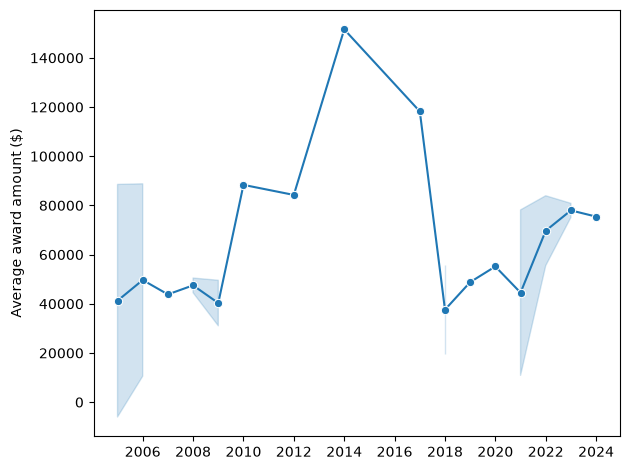

In [13]:
# dfx['Project Type'].unique()
import matplotlib.pyplot as plt
import seaborn as sns

dfu = dfx
dfu = filtered_dfx



dfu["Amount"] = (
    dfu["Award Amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# # Make the time-series plot
# plt.figure(figsize=(12, 6))

dfu["Year"] = pd.to_datetime(dfu["Year"], format="%Y")

sns.lineplot(
    data=dfu,
    x="Year",
    y="Amount",
    marker="o",
    errorbar="sd"
)

plt.xlabel("")
plt.ylabel("Average award amount ($)")

plt.xticks(rotation=0)
plt.tight_layout()

##Save at high res
import os
output_dir = r'F:\Loose figures'
file_name = 'funding_mean_sd_crd_cig.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()

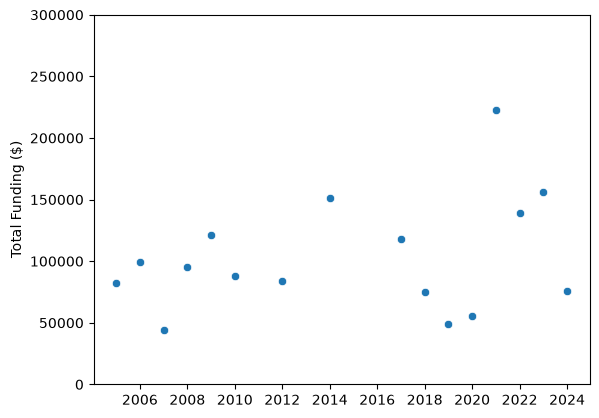

In [14]:
yearly_funding = (
    dfu.groupby("Year", as_index=False)["Amount"]
      .sum()
)

sns.scatterplot(
    data=yearly_funding,
    x="Year",
    y="Amount",
    marker="o"
)

plt.xlabel("")
plt.ylabel("Total Funding ($)")
plt.ylim(0, 300000) 

##Save at high res
import os
output_dir = r'F:\Loose figures'
file_name = 'RESTORATION_SUM_funding_mean_sd_crd_cig.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()

In [15]:
##RETRIEVE COMPANY NAMES FOR NETWORK ANALYSIS

import os
#Export CSV file
out_dir = os.path.expanduser('~/Downloads')
out_csv = os.path.join(out_dir, 'restoration_cig.csv')
# dfu.to_csv(out_csv, index = False)